<a href="https://colab.research.google.com/github/jenyabydaev-web/homeworkk/blob/homework/Hands-on%20%233.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

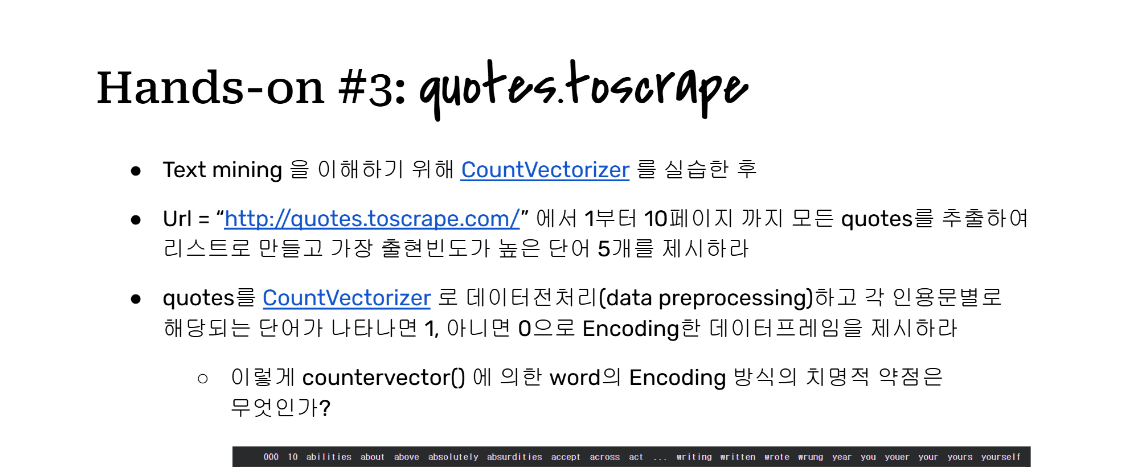

In [ ]:
import requests
from bs4 import BeautifulSoup

# 모든 quotes를 저장할 리스트
quotes = []

# 1페이지부터 10페이지까지 반복
for page in range(1, 11):
    url = f"http://quotes.toscrape.com/page/{page}/"

    # 웹 페이지 요청
    response = requests.get(url)

    # HTML 파싱
    soup = BeautifulSoup(response.text, "html.parser")

    # quote 텍스트 추출
    quote_elements = soup.find_all("span", class_="text")

    # 리스트에 저장
    for q in quote_elements:
        quotes.append(q.text)

# 전체 quote 개수 출력
print(f"총 quotes 개수: {len(quotes)}")

총 quotes 개수: 100


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# 영어 불용어 제거 후 벡터화
vectorizer = CountVectorizer(stop_words='english')

# 텍스트 데이터를 숫자 벡터로 변환
X = vectorizer.fit_transform(quotes)

# 각 단어의 총 등장 횟수 계산
word_counts = X.sum(axis=0)

# 단어 목록 가져오기
words = vectorizer.get_feature_names_out()

# (단어, 빈도수) 형태로 저장
word_freq = list(zip(words, word_counts.tolist()[0]))

# 빈도수 기준으로 내림차순 정렬
word_freq_sorted = sorted(word_freq, key=lambda x: x[1], reverse=True)

# 상위 5개 단어 출력
print("Top 5 단어:")
for word, freq in word_freq_sorted[:5]:
    print(word, freq)

Top 5 단어:
love 23
life 12
think 12
make 10
don 9


In [ ]:
import pandas as pd

# binary=True → 단어가 존재하면 1, 아니면 0
vectorizer_binary = CountVectorizer(binary=True, stop_words='english')

# 변환 수행
X_binary = vectorizer_binary.fit_transform(quotes)

# DataFrame으로 변환
df = pd.DataFrame(
    X_binary.toarray(),
    columns=vectorizer_binary.get_feature_names_out()
)

# 일부 데이터 출력
print(df.head())

   000  10  abilities  absolutely  absurdities  accept  act  actually  \
0    0   0          0           0            0       0    0         0   
1    0   0          1           0            0       0    0         0   
2    0   0          0           0            0       0    0         0   
3    0   0          0           0            0       0    0         0   
4    0   0          0           1            0       0    0         0   

   admiration  admit  ...  worth  worthy  wrap  write  writing  written  \
0           0      0  ...      0       0     0      0        0        0   
1           0      0  ...      0       0     0      0        0        0   
2           0      0  ...      0       0     0      0        0        0   
3           0      0  ...      0       0     0      0        0        0   
4           0      0  ...      0       0     0      0        0        0   

   wrote  wrung  year  youer  
0      0      0     0      0  
1      0      0     0      0  
2      0      0  

CountVectorizer의 치명적인 단점은 무엇인가?

 CountVectorizer의 가장 큰 단점은 단어의 의미(semantic)와 문맥(context)을 고려하지 못한다는 점이다.

 구체적인 문제점:
단어 순서를 고려하지 않음
→ "I love you" 와 "You love I" 를 동일하게 처리함
의미 정보 부족
→ "good" 과 "excellent" 를 완전히 다른 단어로 인식
문맥(Context) 이해 불가능
→ 같은 단어라도 상황에 따라 의미가 달라질 수 있음
단어 중요도 반영 부족
→ 단순 등장 횟수만 사용 (TF-IDF가 더 개선된 방법)